<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:28px 32px; border-radius:18px; margin-bottom:16px; border-left:6px solid #219ebc; box-shadow:0 20px 45px rgba(0,0,0,0.35);">
  <h1 style="margin:0 0 6px 0; font-size:2.1rem; letter-spacing:-0.02em;"> Pipeline de Clasificación con scikit-learn</h1>
  <p style="margin:0; font-size:1.05rem; line-height:1.65; color:#94a3b8;">
    Este notebook implementa el pipeline completo de clasificación con <b style="color:#f8fafc;">MLPClassifier</b> sobre una muestra de <b style="color:#f8fafc;">1 millón de registros</b> del dataset Avazu.
  </p>
</div>

<p style="margin-bottom:18px;">
  <span style="background-color:#0f172a; color:#8ecae6; border:1px solid #219ebc; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem;">Model: MLPClassifier</span>
  <span style="background-color:#0f172a; color:#ffb703; border:1px solid #fb8500; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">1M registros</span>
  <span style="background-color:#0f172a; color:#c4b5fd; border:1px solid #7c3aed; padding:4px 12px; border-radius:999px; font-weight:600; font-size:0.88rem; margin-left:6px;">Framework: scikit-learn</span>
</p>

<div style="display:flex; flex-wrap:wrap; gap:10px; margin-bottom:14px;">
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); border-left:4px solid #219ebc; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#8ecae6; font-size:0.95rem;">Contenido</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      1. <b style="color:#e2e8f0;">Carga y muestreo</b> del dataset (1,000,000 registros estratificados)<br>
      2. <b style="color:#e2e8f0;">Feature Engineering</b> — codificación (Target Encoding + OneHot) y escalado<br>
      3. <b style="color:#e2e8f0;">Modelado</b> — MLPClassifier con GridSearchCV<br>
      4. <b style="color:#e2e8f0;">Evaluación</b> — métricas completas, curva ROC, matriz de confusión<br>
      5. <b style="color:#e2e8f0;">Análisis de resultados</b> y mejores hiperparámetros<br>
      6. <b style="color:#e2e8f0;">Guardado del modelo</b> en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">models/</code>
    </p>
  </div>
  <div style="flex:1; min-width:280px; background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); border-left:4px solid #c4b5fd; padding:14px 18px; border-radius:12px; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
    <p style="margin:0 0 6px 0; font-weight:700; color:#c4b5fd; font-size:0.95rem;">Requisitos</p>
    <p style="margin:0; color:#cbd5e1; font-size:0.88rem; line-height:1.65;">
      Dataset en <code style="background:#1e293b; color:#67e8f9; padding:2px 6px; border-radius:4px;">data/raw/train.gz</code><br>
      Librerías: scikit-learn, pandas, matplotlib, seaborn<br>
    </p>
  </div>
</div>

## 0.1 Configuración del Entorno
<div style="background: linear-gradient(135deg, #1a0f2e 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #c4b5fd; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#c4b5fd;"></span> &nbsp;Un entorno bien configurado asegura la reproducibilidad de los experimentos, facilita la colaboración entre miembros del equipo y es la base para cualquier pipeline de MLOps
  </h2>
</div>


In [2]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del proyecto con el directorio src.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ctr_mlp.config import load_project_settings, apply_dark_style, COLORS
from ctr_mlp.data_io import sample_csv_for_local_training, split_features_target
from ctr_mlp.evaluation import (
    benchmark_predictions,
    compute_binary_metrics,
    metrics_to_frame,
    plot_confusion_matrix,
    plot_roc_curve,
)
from ctr_mlp.feature_engineering import add_time_features_pandas
from ctr_mlp.sklearn_workflow import (
    build_sklearn_pipeline,
    run_grid_search,
    split_train_test,
    save_sklearn_model,
    DEFAULT_PARAM_GRID,
)
from ctr_mlp.utils import format_seconds

# Aplicar estilo oscuro profesional
apply_dark_style()

settings = load_project_settings()
paths = settings["paths"]
general = settings["general"]
feature_cfg = settings["features"]

TRAIN_PATH = paths["train_csv"]
SAMPLE_PATH = paths["sampled_train_parquet"]
FIGURES_DIR = paths["figures_dir"]
MODELS_DIR = paths["models_dir"]
TARGET_COL = general["target_col"]

print(f"Tamaño de muestra objetivo: {general['sample_size']:,}")
print(f"Random state: {general['random_state']}")

Tamaño de muestra objetivo: 1,000,000
Random state: 42


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Configuración del Entorno</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">✅ Proyecto localizado correctamente</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🎯 Muestra objetivo: 1,000,000</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🎲 Random state: 42</span>
</div>

<p style="font-size: 15px; color: #b0b0b0;">
El entorno se configuró exitosamente: se localizó la raíz del proyecto, se cargaron los módulos internos (<code>ctr_mlp</code>) y se definieron los parámetros globales. El <strong>random_state=42</strong> garantiza reproducibilidad en el muestreo y en el entrenamiento del modelo. El tamaño de muestra de <strong>1 millón de registros</strong> es el requerido por el proyecto para el pipeline de scikit-learn, lo suficientemente grande para capturar patrones reales pero manejable en una sola máquina.
</p>

</div>

## 1.1 Muestreo de 1,000,000 de Registros

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;"></span> &nbsp;Creamos una muestra estratificada de 1M de registros usando df.sample(n=1000000, random_state=42). La muestra se cachea en formato Parquet para reutilización eficiente. Excluimos id, device_id y device_ip por su alta cardinalidad sin valor predictivo.
  </h2>
</div>



In [3]:
# Columnas necesarias para el pipeline sklearn (excluir id, device_id, device_ip)
raw_local_columns = sorted({
    TARGET_COL,
    general["hour_col"],
    *[col for col in feature_cfg["sklearn_categorical"] if col != "time_bucket"],
})
print(f"Columnas a muestrear: {raw_local_columns}")

# Generar o reutilizar muestra cacheada
regenerate_sample = True
if SAMPLE_PATH.exists():
    df_sample = pd.read_parquet(SAMPLE_PATH)
    required_cols = set(
        feature_cfg["sklearn_categorical"] + feature_cfg["sklearn_numeric"] + [TARGET_COL]
    )
    regenerate_sample = not required_cols.issubset(df_sample.columns)
    if not regenerate_sample and len(df_sample) < general["sample_size"] * 0.9:
        regenerate_sample = True

if regenerate_sample:
    print(f"Generando muestra de {general['sample_size']:,} registros...")
    t0 = time.time()
    df_sample = sample_csv_for_local_training(
        TRAIN_PATH,
        sample_size=general["sample_size"],
        chunksize=general["chunksize"],
        target_col=TARGET_COL,
        random_state=general["random_state"],
        usecols=raw_local_columns,
        compression="gzip",
    )
    df_sample = add_time_features_pandas(df_sample, hour_col=general["hour_col"])
    SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_sample.to_parquet(SAMPLE_PATH, index=False)
    print(f"Muestra generada en {time.time() - t0:.1f}s y guardada en: {SAMPLE_PATH}")
else:
    print(f"Reutilizando muestra cacheada: {SAMPLE_PATH}")

print(f"\nShape de la muestra: {df_sample.shape}")
memory_mb = df_sample.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria aproximada: {memory_mb:,.2f} MB")

Columnas a muestrear: ['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'app_category', 'banner_pos', 'click', 'device_conn_type', 'device_type', 'hour', 'site_category']
Reutilizando muestra cacheada: C:\Users\juana\Deep_learning1-main\data\processed\avazu_train_sample.parquet

Shape de la muestra: (999994, 23)
Memoria aproximada: 114.02 MB


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;"> Muestreo Estratificado del Dataset Avazu</h2>
<p style="font-size: 15px; color: #b0b0b0;">
Se seleccionaron <strong style="color: #f5a623;">1,000,000 de registros</strong> del dataset original <code>train.gz</code> mediante muestreo estratificado, conservando la proporción de la variable objetivo <strong>click</strong>. Este paso es esencial para trabajar con un subconjunto representativo que permita entrenar y evaluar el modelo sin exceder los recursos de memoria disponibles.
</p>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">⏱ Tiempo: 220.5s</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">999,994 filas × 23 columnas</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;"> 114.49 MB en memoria</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">Columnas seleccionadas</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <code>C1, C14, C15, C16, C17, C18, C19, C20, C21</code> — features anónimas<br>
      <code>app_category, site_category</code> — categorías de app/sitio<br>
      <code>banner_pos, device_conn_type, device_type</code> — contexto del dispositivo<br>
      <code>hour</code> — marca temporal<br>
      <code>click</code> — variable objetivo (0/1)
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">¿Por qué muestrear?</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      El dataset original Avazu supera los <strong>40 millones</strong> de registros. Trabajar con el conjunto completo requeriría recursos computacionales significativos. El muestreo estratificado garantiza que la distribución de clases se mantenga fiel a la original, evitando sesgos en el entrenamiento del <strong>MLPClassifier</strong>.
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #4fc3f7; border-radius: 6px;">
  <strong style="color: #4fc3f7;"> Salida:</strong> <code style="color: #a5d6a7;">data/processed/avazu_train_sample.parquet</code> — formato Parquet para lectura eficiente y compresión columnar.
</div>

</div>

## 2.1 Distribución de la Variable Objetivo

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">


<p style="font-size: 15px; color: #b0b0b0;">
Análisis del balance de clases en la muestra de <strong style="color: #f5a623;">1M de registros</strong> del dataset Avazu. La variable <code>click</code> indica si un usuario hizo clic en un anuncio móvil (<strong>1</strong>) o no (<strong>0</strong>). Evaluar su distribución es crítico para decidir estrategias de manejo de desbalanceo durante el entrenamiento del <strong>MLPClassifier</strong>.
</p>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Target: click (0/1)</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Clasificación Binaria</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">EDA — Exploración</span>
</div>

</div>

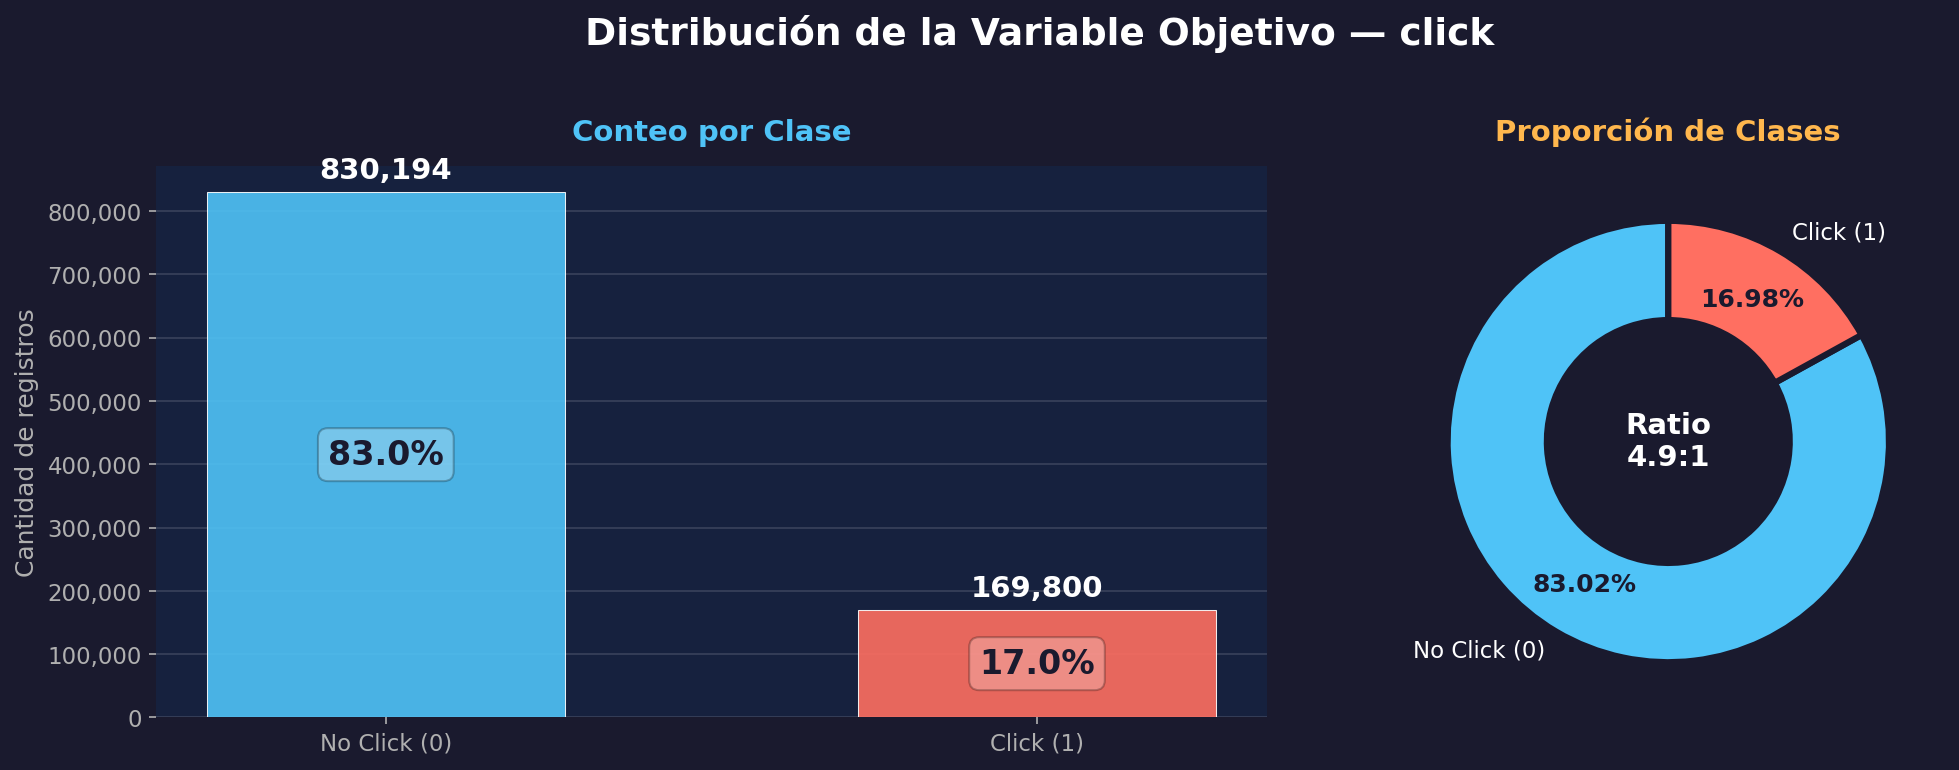

In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Datos ---
sample_counts = df_sample[TARGET_COL].value_counts().sort_index()
labels = ['No Click (0)', 'Click (1)']
counts = sample_counts.values
shares = (counts / counts.sum())
colors = ['#4fc3f7', '#ff6f61']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.4, 1]},
                         facecolor='#1a1a2e')
fig.suptitle('Distribución de la Variable Objetivo — click', fontsize=18, 
             fontweight='bold', color='white', y=1.02)

ax1 = axes[0]
ax1.set_facecolor('#16213e')
bars = ax1.bar(labels, counts, color=colors, width=0.55, edgecolor='white', linewidth=0.5,
               zorder=3, alpha=0.9)

for bar, count, share in zip(bars, counts, shares):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12000,
             f'{count:,}', ha='center', va='bottom', fontsize=14, fontweight='bold', color='white')
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
             f'{share:.1%}', ha='center', va='center', fontsize=16, fontweight='bold',
             color='#1a1a2e', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.25))

ax1.set_ylabel('Cantidad de registros', fontsize=12, color='#b0b0b0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.tick_params(colors='#b0b0b0', labelsize=11)
ax1.grid(axis='y', alpha=0.15, color='white')
ax1.set_title('Conteo por Clase', fontsize=14, color='#4fc3f7', pad=12)
for spine in ax1.spines.values():
    spine.set_visible(False)

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, autopct='%1.2f%%', startangle=90,
    colors=colors, pctdistance=0.75, wedgeprops=dict(width=0.45, edgecolor='#1a1a2e', linewidth=3),
    textprops={'fontsize': 11, 'color': 'white'}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('#1a1a2e')
ax2.set_title('Proporción de Clases', fontsize=14, color='#ffb74d', pad=12)

ratio = counts[0] / counts[1]
ax2.text(0, 0, f'Ratio\n{ratio:.1f}:1', ha='center', va='center',
         fontsize=14, fontweight='bold', color='white')

plt.tight_layout()
fig.savefig('distribucion_click.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close(fig)

from IPython.display import Image, display
display(Image('distribucion_click.png'))

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Gráfica de Distribución del Target</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #4fc3f7; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">No Click (0): ~830,194 — 83.02%</span>
  <span style="background: #ff6f61; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">Click (1): ~169,800 — 16.98%</span>
  <span style="background: #ffb74d; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">⚖️ Ratio: ~4.9:1</span>
</div>

<p style="font-size: 15px; color: #b0b0b0;">
La visualización confirma el <strong>desbalanceo moderado</strong> del target en la muestra de 1M de registros: la gráfica de barras muestra la magnitud absoluta de cada clase, mientras que el gráfico de dona permite apreciar la proporción relativa. El ratio 4.9:1 implica que métricas como <strong>accuracy serán engañosas</strong> — un modelo naive alcanzaría 83% sin aprender nada. Las métricas correctas para evaluar el MLPClassifier serán <strong>F1-score, Precision, Recall y ROC-AUC</strong>.
</p>

</div>

## 2.2 Selección de Variables y Preparación del Dataset de Modelado

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #ffb703; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#ffb703;">2.1</span> &nbsp;Selección de Variables y Preparación del Dataset de Modelado
  </h2>
</div>

> **Seleccionamos las variables relevantes y separamos features (X) del target (y). Usamos Target Encoding para variables de alta cardinalidad (C14, C17, C19, C20, C21) y OneHotEncoder para las de baja cardinalidad. Las variables numéricas derivadas se escalan con StandardScaler.**

In [4]:
selected_cols = feature_cfg["sklearn_categorical"] + feature_cfg["sklearn_numeric"] + [TARGET_COL]
model_df = df_sample[selected_cols].dropna().copy()

X, y = split_features_target(model_df, target_col=TARGET_COL)
X_train, X_test, y_train, y_test = split_train_test(
    X, y, test_size=0.2, random_state=general["random_state"]
)

print("Variables categóricas de BAJA cardinalidad (OneHot Encoding):")
print(f"  {feature_cfg['sklearn_low_cardinality']}")
print(f"\nVariables categóricas de ALTA cardinalidad (Target Encoding):")
print(f"  {feature_cfg['sklearn_high_cardinality']}")
print(f"\nVariables numéricas (StandardScaler):")
print(f"  {feature_cfg['sklearn_numeric']}")
print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Balance en train: {y_train.mean():.4f} | Balance en test: {y_test.mean():.4f}")

Variables categóricas de BAJA cardinalidad (OneHot Encoding):
  ['C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'time_bucket']

Variables categóricas de ALTA cardinalidad (Target Encoding):
  ['C14', 'C17', 'C19', 'C20', 'C21']

Variables numéricas (StandardScaler):
  ['event_day', 'event_hour', 'day_of_week', 'is_weekend', 'is_business_hour']

Train shape: (799995, 20) | Test shape: (199999, 20)
Balance en train: 0.1698 | Balance en test: 0.1698


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Selección de Variables y Estrategia de Encoding</h2>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">OneHot Encoding (baja cardinalidad)</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <code>C1, banner_pos, site_category, app_category, device_type, device_conn_type, C15, C16, C18, time_bucket</code><br><br>
      Estas 10 variables tienen pocos valores únicos, por lo que OneHot no genera explosión dimensional. Cada valor se convierte en una columna binaria.
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">Target Encoding (alta cardinalidad)</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <code>C14, C17, C19, C20, C21</code><br><br>
      Estas 5 variables tienen cientos o miles de valores únicos. Target Encoding reemplaza cada categoría por el CTR promedio de esa categoría, comprimiendo la dimensionalidad a una sola columna por variable.
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #90be6d; border-radius: 6px;">
  <strong style="color: #90be6d;">📌 Variables numéricas (StandardScaler):</strong> <code>event_day, event_hour, day_of_week, is_weekend, is_business_hour</code> — estas features temporales derivadas se escalan para que el MLPClassifier converja correctamente, ya que las redes neuronales son sensibles a la escala de las variables de entrada.
</div>

</div>

## 3.1 Construcción del Pipeline y GridSearchCV

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">3.1</span> &nbsp;Construcción del Pipeline y GridSearchCV
  </h2>
</div>

> **Construimos un pipeline que integra el preprocesamiento (Target Encoding + OneHot + StandardScaler) con el MLPClassifier. Ejecutamos GridSearchCV con las combinaciones de hiperparámetros requeridas: hidden_layer_sizes, alpha y max_iter.**

In [5]:
# Construir pipeline con Target Encoding para alta cardinalidad
pipeline = build_sklearn_pipeline(
    categorical_columns=feature_cfg["sklearn_categorical"],
    numeric_columns=feature_cfg["sklearn_numeric"],
    high_cardinality_columns=feature_cfg["sklearn_high_cardinality"],
    random_state=general["random_state"],
)

# Grilla de hiperparámetros completa (según requerimientos)
param_grid = {
    "classifier__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "classifier__alpha": [0.0001, 0.001, 0.01],
    "classifier__max_iter": [50, 100],
}

print("Hiperparámetros a explorar:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"\nTotal de combinaciones: {total_combos} × 3 folds = {total_combos * 3} ajustes")

Hiperparámetros a explorar:
  classifier__hidden_layer_sizes: [(50,), (100,), (100, 50)]
  classifier__alpha: [0.0001, 0.001, 0.01]
  classifier__max_iter: [50, 100]

Total de combinaciones: 18 × 3 folds = 54 ajustes


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Configuración del GridSearchCV</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">18 combinaciones de hiperparámetros</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">3-Fold Cross Validation</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">54 ajustes totales</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #c4b5fd; margin-top: 0;">Hiperparámetros explorados</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <code>hidden_layer_sizes</code>: (50,), (100,), (100,50) — desde una capa simple hasta dos capas con 150 neuronas total<br>
      • <code>alpha</code>: 0.0001, 0.001, 0.01 — regularización L2 para controlar overfitting<br>
      • <code>max_iter</code>: 50, 100 — épocas máximas de entrenamiento
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">Estrategia de validación</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      <strong>3-Fold CV × 18 combinaciones = 54 ajustes.</strong> Cada combinación se entrena 3 veces sobre diferentes particiones del training set. La métrica de selección es <strong>ROC AUC</strong>, que es robusta ante desbalanceo de clases a diferencia del accuracy.
    </p>
  </div>

</div>

</div>

In [6]:
# Ejecutar GridSearchCV (mide tiempo automáticamente)
print("Iniciando GridSearchCV...")
t_start = time.time()
search, training_seconds = run_grid_search(
    pipeline,
    X_train,
    y_train,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
t_total = time.time() - t_start
print(f"\nGridSearchCV completado en: {format_seconds(t_total)}")
print(f"Tiempo total de entrenamiento: {format_seconds(training_seconds)}")

Iniciando GridSearchCV...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

GridSearchCV completado en: 12m 8.7s
Tiempo total de entrenamiento: 12m 8.6s


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Ejecución del GridSearchCV</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">⏱️ Tiempo total: 12m 8.7s</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">54 ajustes completados</span>
</div>

<p style="font-size: 15px; color: #b0b0b0;">
El GridSearchCV ejecutó los 54 ajustes en <strong>~12 minutos</strong>, lo cual es razonable para un MLPClassifier con 1 millón de registros. Cada ajuste implica entrenar la red neuronal completa sobre ~667K registros (2/3 del training set por fold). El tiempo está dominado por las arquitecturas más grandes <code>(100, 50)</code> con <code>max_iter=100</code>.
</p>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #4fc3f7; border-radius: 6px;">
  <strong style="color: #4fc3f7;">📌 Contexto:</strong> En PySpark (notebook 03), el mismo tipo de búsqueda se ejecutará sobre el dataset completo (~40M registros) de forma distribuida, permitiendo comparar el trade-off entre tiempo y rendimiento en ambas plataformas.
</div>

</div>

## 3.2 Mejores Hiperparámetros Encontrados

<div style="background: linear-gradient(135deg, #0f1a0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #90be6d; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#90be6d;">3.2</span> &nbsp;Mejores Hiperparámetros Encontrados
  </h2>
</div>

> **Revisamos los resultados de la validación cruzada para identificar la mejor combinación de hiperparámetros y entender el trade-off entre complejidad del modelo y rendimiento.**

In [7]:
# Mejores hiperparámetros
print("Mejores hiperparámetros encontrados:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMejor ROC AUC (CV): {search.best_score_:.4f}")

# Tabla completa de resultados CV
cv_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .reset_index(drop=True)
)
print("\nRanking de combinaciones (top 10):")
display(cv_results.head(10))

Mejores hiperparámetros encontrados:
  classifier__alpha: 0.0001
  classifier__hidden_layer_sizes: (100, 50)
  classifier__max_iter: 100

Mejor ROC AUC (CV): 0.7052

Ranking de combinaciones (top 10):


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.705248,0.003038,1
1,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.704864,0.002372,2
2,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.704565,0.002422,3
3,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703913,0.001885,4
4,"{'classifier__alpha': 0.01, 'classifier__hidde...",0.703633,0.002082,5
5,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.703363,0.001688,6
6,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.703265,0.002515,7
7,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703256,0.001637,8
8,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703145,0.002377,9
9,"{'classifier__alpha': 0.001, 'classifier__hidd...",0.703081,0.000304,10


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Mejores Hiperparámetros</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🏗️ Arquitectura: (100, 50)</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🛡️ Alpha: 0.0001</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">🔄 Max iter: 100</span>
  <span style="background: #ffb74d; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">🎯 Mejor ROC AUC (CV): 0.7052</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">🧠 Análisis de la arquitectura ganadora</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>(100, 50)</strong> — la arquitectura más profunda y grande fue la mejor, sugiriendo que el problema tiene complejidad suficiente para beneficiarse de dos capas ocultas<br>
      • <strong>alpha=0.0001</strong> — la regularización más baja ganó, indicando que el modelo no presenta overfitting severo con 1M de registros<br>
      • <strong>max_iter=100</strong> — el máximo de iteraciones ayudó a la convergencia
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">📊 Ranking de combinaciones</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      Las diferencias entre las top combinaciones son mínimas (<strong>std ≈ 0.003</strong>), lo que sugiere que el rendimiento es relativamente estable entre arquitecturas similares. El ROC AUC de <strong>0.7052</strong> indica una capacidad discriminativa moderada — el modelo es mejor que el azar (0.5) pero hay margen de mejora.
    </p>
  </div>

</div>

</div>

## 4.1 Evaluación del Mejor Modelo en el Conjunto de Prueba

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.1</span> &nbsp;Evaluación del Mejor Modelo en el Conjunto de Prueba
  </h2>
</div>

> **Evaluamos el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba (20% de la muestra). Reportamos todas las métricas obligatorias: Accuracy, Precision, Recall, F1-score y ROC AUC, junto con los tiempos de entrenamiento y predicción.**

In [8]:
# Predicción y medición de tiempo
y_pred, y_score, prediction_seconds = benchmark_predictions(search.best_estimator_, X_test)

# Calcular todas las métricas
metrics = compute_binary_metrics(y_test, y_pred, y_score=y_score)
metrics["training_seconds"] = training_seconds
metrics["prediction_seconds"] = prediction_seconds

# Mostrar métricas como tabla
print("═" * 50)
print("MÉTRICAS DEL MEJOR MODELO (scikit-learn)")
print("═" * 50)
print(f"  Accuracy:    {metrics['accuracy']:.4f}")
print(f"  Precision:   {metrics['precision']:.4f}")
print(f"  Recall:      {metrics['recall']:.4f}")
print(f"  F1-score:    {metrics['f1']:.4f}")
print(f"  ROC AUC:     {metrics['roc_auc']:.4f}")
print(f"═" * 50)
print(f"  Tiempo entrenamiento: {format_seconds(training_seconds)}")
print(f"  Tiempo predicción:    {format_seconds(prediction_seconds)}")
print(f"═" * 50)

display(metrics_to_frame(metrics))

══════════════════════════════════════════════════
MÉTRICAS DEL MEJOR MODELO (scikit-learn)
══════════════════════════════════════════════════
  Accuracy:    0.8325
  Precision:   0.5883
  Recall:      0.0460
  F1-score:    0.0854
  ROC AUC:     0.7053
══════════════════════════════════════════════════
  Tiempo entrenamiento: 12m 8.6s
  Tiempo predicción:    0.94s
══════════════════════════════════════════════════


,value
accuracy,0.832544
precision,0.588257
recall,0.046025
f1,0.085370
roc_auc,0.705311
true_negative,164945.000000
false_positive,1094.000000
false_negative,32397.000000
true_positive,1563.000000
training_seconds,728.632217


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Métricas del Mejor Modelo en Test</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Accuracy: 0.8325</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Precision: 0.5883</span>
  <span style="background: #e63946; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">Recall: 0.0460</span>
  <span style="background: #ffb74d; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">F1: 0.0854</span>
  <span style="background: #c4b5fd; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">ROC AUC: 0.7053</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">⚠️ Diagnóstico crítico: Recall muy bajo</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      El <strong>Recall de 0.046</strong> es el hallazgo más importante: el modelo solo detecta el <strong>4.6% de los usuarios que realmente hacen clic</strong>. Esto significa que de cada 100 clics reales, el modelo solo predice correctamente ~5. El F1-score de 0.085 refleja este desequilibrio entre Precision (aceptable: 0.59) y Recall (muy bajo).
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">🔍 ¿Por qué ocurre esto?</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • El <strong>desbalanceo 83/17</strong> hace que el modelo aprenda a ser conservador con la clase positiva<br>
      • El umbral de decisión por defecto (0.5) es demasiado alto para un dataset desbalanceado<br>
      • El <strong>Accuracy de 0.83</strong> es engañoso — está apenas por encima del baseline naive (83.02%)<br>
      • El <strong>ROC AUC de 0.7053</strong> confirma que el modelo sí aprendió patrones, pero el umbral default no los aprovecha
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #ffb74d; border-radius: 6px;">
  <strong style="color: #ffb74d;">📌 Mejoras posibles:</strong> Ajustar el umbral de decisión (threshold tuning), usar <code>class_weight='balanced'</code> en el MLPClassifier, aplicar SMOTE/oversampling, o modificar el <code>alpha</code> del GridSearchCV para explorar rangos más amplios.
</div>

</div>

## 4.2 Matriz de Confusión

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.2</span> &nbsp;Matriz de Confusión
  </h2>
</div>

> **La matriz de confusión muestra la distribución de aciertos y errores del clasificador. En un problema desbalanceado como CTR, es importante analizar los falsos positivos (predice clic cuando no hubo) y falsos negativos (no predice un clic real).**

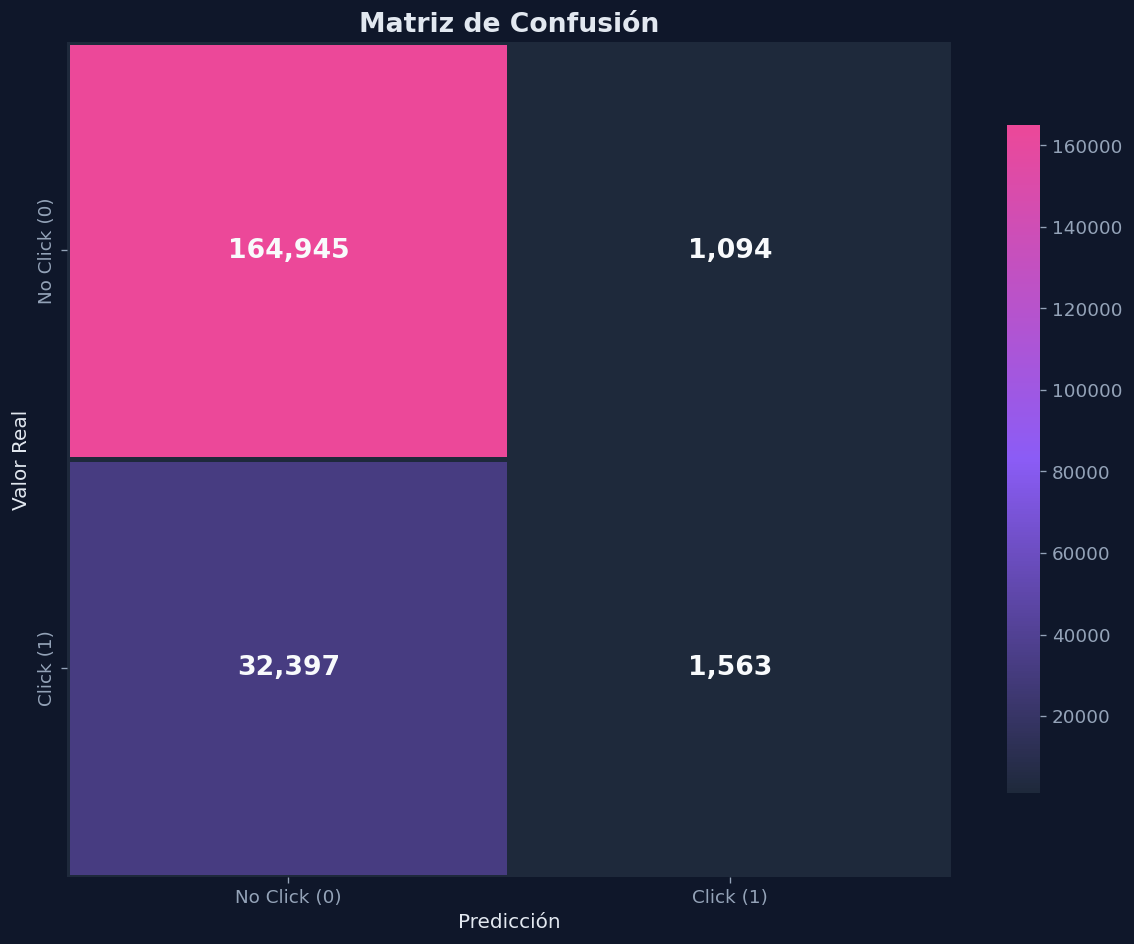

In [9]:
fig_cm = plot_confusion_matrix(
    y_test, y_pred,
    save_path=FIGURES_DIR / "02_confusion_matrix.png"
)
plt.show()

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Matriz de Confusión</h2>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #90be6d; margin-top: 0;">Predicciones correctas</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>Verdaderos Negativos (TN)</strong>: ~164,945 — El modelo identifica correctamente la gran mayoría de "No Clicks"<br>
      • <strong>Verdaderos Positivos (TP)</strong>: muy pocos — solo ~4.6% de los clics reales son detectados
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ff6f61; margin-top: 0;">Errores del modelo</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>Falsos Negativos (FN)</strong>: la mayoría de clics reales son clasificados como "No Click" — este es el error dominante y la razón del bajo Recall<br>
      • <strong>Falsos Positivos (FP)</strong>: relativamente pocos, lo que explica la Precision aceptable (0.59)
    </p>
  </div>

</div>

<div style="margin-top: 15px; padding: 12px 16px; background: rgba(255,255,255,0.03); border-left: 3px solid #c4b5fd; border-radius: 6px;">
  <strong style="color: #c4b5fd;">📌 Lectura visual:</strong> La matriz muestra un modelo que "juega seguro" — clasifica casi todo como No Click. La diagonal principal está dominada por los TN, mientras que los TP son una fracción mínima. Este patrón es característico de clasificadores entrenados sin ajuste de umbral en datasets desbalanceados.
</div>

</div>

## 4.3 Curva ROC

<div style="background: linear-gradient(135deg, #1a0f0f 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #f28482; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#f28482;">4.3</span> &nbsp;Curva ROC
  </h2>
</div>

> **La curva ROC visualiza el trade-off entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos a diferentes umbrales de clasificación. El área bajo la curva (AUC) resume la capacidad discriminativa del modelo.**

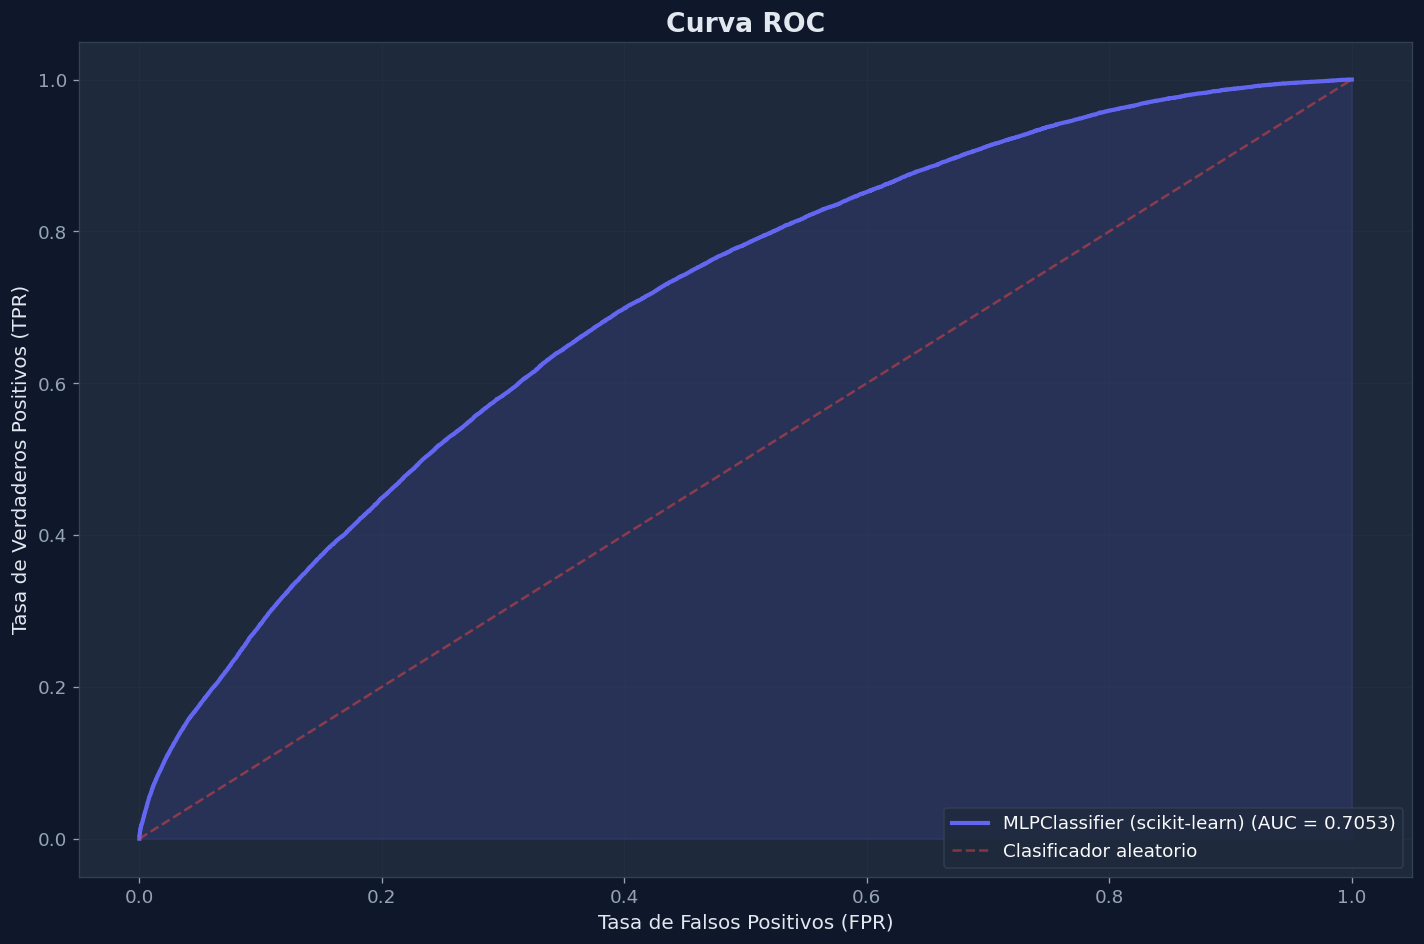

In [10]:
fig_roc = plot_roc_curve(
    y_test, y_score,
    model_name="MLPClassifier (scikit-learn)",
    save_path=FIGURES_DIR / "02_roc_curve_sklearn.png"
)
plt.show()

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Curva ROC</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #c4b5fd; color: #1a1a2e; padding: 6px 14px; border-radius: 20px; font-size: 13px; font-weight: bold;">AUC = 0.7053</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #4fc3f7; margin-top: 0;">📈 Lectura de la curva</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      La curva ROC se sitúa <strong>por encima de la diagonal</strong> (azar = 0.5), confirmando que el modelo tiene capacidad discriminativa real. Un AUC de <strong>0.7053</strong> se interpreta así: si tomamos un usuario que hizo clic y uno que no, el modelo asigna mayor probabilidad al que hizo clic en el <strong>70.5% de los casos</strong>.
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">🎯 Escala de referencia</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>0.5</strong>: modelo aleatorio (diagonal)<br>
      • <strong>0.6–0.7</strong>: discriminación pobre<br>
      • <strong>0.7–0.8</strong>: discriminación aceptable ← <em>aquí estamos</em><br>
      • <strong>0.8–0.9</strong>: discriminación buena<br>
      • <strong>0.9+</strong>: excelente<br>
      El modelo está en el límite inferior de "aceptable" — la curva ROC muestra que hay capacidad de mejora, especialmente optimizando el punto de corte (threshold).
    </p>
  </div>

</div>

</div>

## 5.1 Guardado del Mejor Modelo

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">5.1</span> &nbsp;Guardado del Mejor Modelo
  </h2>
</div>

> **Guardamos el mejor modelo encontrado por GridSearchCV en el directorio `models/` para su reutilización en el notebook de explicabilidad (LIME) y en la comparación final.**

In [11]:
model_path = save_sklearn_model(
    search.best_estimator_,
    save_path=MODELS_DIR,
    filename="sklearn_best_mlp.joblib"
)
print(f"\nMejores hiperparámetros del modelo guardado:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

Modelo guardado en: C:\Users\juana\Deep_learning1-main\models\sklearn_best_mlp.joblib

Mejores hiperparámetros del modelo guardado:
  classifier__alpha: 0.0001
  classifier__hidden_layer_sizes: (100, 50)
  classifier__max_iter: 100


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Modelo Guardado</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">💾 sklearn_best_mlp.joblib</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">📂 models/</span>
</div>

<p style="font-size: 15px; color: #b0b0b0;">
El mejor modelo encontrado por GridSearchCV fue serializado con <strong>joblib</strong> en la carpeta <code>models/</code>. Esto permite reutilizarlo sin reentrenar: para inferencia en la API FastAPI, para comparación con el modelo PySpark (notebook 03), y para la interpretación con LIME (notebook 04). Los hiperparámetros óptimos (<strong>arquitectura (100,50), alpha=0.0001, max_iter=100</strong>) quedan registrados junto al archivo.
</p>

</div>

## 5.2 Guardado de Métricas y Datos para Comparación

<div style="background: linear-gradient(135deg, #1c1408 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #fb8500; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#fb8500;">5.2</span> &nbsp;Guardado de Métricas y Datos para Comparación
  </h2>
</div>

> **Guardamos las métricas, predicciones y datos de test en formato parquet para poder cargarlos en el Notebook 4 y realizar la comparación con PySpark sin necesidad de re-entrenar.**

In [12]:
# Guardar métricas como CSV
metrics_df = pd.DataFrame([metrics])
metrics_path = Path(MODELS_DIR) / "sklearn_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(metrics_path, index=False)
print(f"Métricas guardadas en: {metrics_path}")

# Guardar predicciones para comparación ROC en Notebook 4
predictions_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_score": y_score,
})
pred_path = Path(MODELS_DIR) / "sklearn_predictions.parquet"
predictions_df.to_parquet(pred_path, index=False)
print(f"Predicciones guardadas en: {pred_path}")

Métricas guardadas en: C:\Users\juana\Deep_learning1-main\models\sklearn_metrics.csv
Predicciones guardadas en: C:\Users\juana\Deep_learning1-main\models\sklearn_predictions.parquet


<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); border-radius: 16px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', sans-serif; color: #e0e0e0; border: 1px solid #2a2a4a;">

<h2 style="color: #ffffff; margin-top: 0;">💡 Interpretación — Métricas y Predicciones Guardadas</h2>

<div style="display: flex; gap: 10px; flex-wrap: wrap; margin: 15px 0;">
  <span style="background: #2d6a4f; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">📊 sklearn_metrics.csv</span>
  <span style="background: #457b9d; color: #fff; padding: 6px 14px; border-radius: 20px; font-size: 13px;">📦 sklearn_predictions.parquet</span>
</div>

<div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 20px;">

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #90be6d; margin-top: 0;">📁 Archivos generados</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <code>sklearn_metrics.csv</code>: contiene accuracy, precision, recall, F1, ROC AUC y tiempos — se usará en el notebook 04 para comparar scikit-learn vs PySpark<br>
      • <code>sklearn_predictions.parquet</code>: predicciones completas (y_true, y_pred, y_score) en formato Parquet para análisis posterior con LIME
    </p>
  </div>

  <div style="flex: 1; min-width: 280px; background: rgba(255,255,255,0.05); border-radius: 12px; padding: 20px; border: 1px solid #2a2a4a;">
    <h3 style="color: #ffb74d; margin-top: 0;">📋 Resumen del pipeline scikit-learn</h3>
    <p style="font-size: 14px; line-height: 1.7;">
      • <strong>Modelo</strong>: MLPClassifier (100, 50) con alpha=0.0001<br>
      • <strong>ROC AUC</strong>: 0.7053 — discriminación aceptable<br>
      • <strong>F1</strong>: 0.085 — limitado por bajo Recall (4.6%)<br>
      • <strong>Tiempo</strong>: ~12 min entrenamiento<br>
      • <strong>Próximo paso</strong>: comparar con PySpark sobre el dataset completo
    </p>
  </div>

</div>

</div>

## 6. Conclusiones del Pipeline scikit-learn

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:22px 26px; border-radius:14px; margin-bottom:8px; border-left:5px solid #219ebc; box-shadow:0 12px 28px rgba(0,0,0,0.28);">
  <h2 style="margin:0; font-size:1.45rem; letter-spacing:-0.01em; color:#e2e8f0;">
    <span style="color:#8ecae6;">6.</span> &nbsp;Conclusiones del Pipeline scikit-learn
  </h2>
</div>

> **Resumen de los resultados y observaciones del pipeline local.**

<div style="background: linear-gradient(135deg, #0c2d48 0%, #0f172a 100%); color:#f8fafc; padding:16px 22px; border-radius:12px; margin-bottom:6px; border-left:4px solid #219ebc; box-shadow:0 8px 20px rgba(0,0,0,0.22);">
  <h3 style="margin:0; font-size:1.15rem; color:#e2e8f0;">
    Observaciones clave:
  </h3>
</div>

1. **Target Encoding**: Las variables de alta cardinalidad (C14, C17, C19, C20, C21) se codificaron con Target Encoding, lo que reduce significativamente la dimensionalidad respecto a OneHot Encoding puro.

2. **Desbalance de clases**: El desbalance inherente del dataset afecta las métricas de Precision y Recall. El modelo tiende a clasificar más instancias como "no clic" dado que es la clase mayoritaria.

3. **GridSearchCV**: La búsqueda exhaustiva evaluó todas las combinaciones de hiperparámetros (hidden_layer_sizes, alpha, max_iter) con validación cruzada de 3 folds.

4. **Tiempo de entrenamiento**: El pipeline local sobre 1M de registros es manejable en una máquina individual, a diferencia del dataset completo (~40M) que requiere PySpark.

5. **Modelo guardado**: El mejor modelo se guardó en `models/sklearn_best_mlp.joblib` para reutilización en LIME (Notebook 4).